# Axial stage root locus
this notebook shows the calculation of the root locus of an axial stage, for varying value of the inter-row gap. The problem is completely described in the exercise 5.4.3 of Spakovszky PhD thesis.
This version makes use only of functions.py. Another version, using the classes implementation will follow

### import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from spakovszky.src.functions import *

### input data
definition of the input data that don't depend on the value of the inter-stage gap, that will be the variable of our problem

In [2]:
Vx1 = 0.34  # non dimensional background axial flow velocity at inlet
Vy1 = 0  # non dimensional background azimuthal flow velocity at outlet

# rotor parameters (pag. 147)
beta1 = -71.1 * np.pi / 180  # relative inlet swirl
alfa1 = 0 * np.pi / 180  # absolute inlet swirl
beta2 = -35 * np.pi / 180  # relative outlet swirl
alfa2 = 65.7 * np.pi / 180  # absolute outlet swirl
dLr_dPhi = -0.6938  # steady state rotor loss derivative at background condition
dLr_dTanb = dLr_dPhi / ((np.tan(alfa1) - np.tan(beta1)) ** 2)  # steady state rotor loss derivative at background condition
c_r = 0.135  # blade chord
gamma_r = -50.2 * np.pi / 180  # stagger angle rotor blades
lambda_r = 0.212  # inertia parameter rotor

# stator parameters (pag. 147)
beta3 = -35 * np.pi / 180  # relative inlet swirl
alfa3 = 65.7 * np.pi / 180  # absolute inlet swirl
beta4 = -71.1 * np.pi / 180  # relative outlet swirl
alfa4 = 0.0 * np.pi / 180  # absolute outlet swirl
dLs_dTana = 0.0411  # steady state stator loss at inlet condition of the stator
c_s = 0.121  # blade chord
gamma_s = 61.8 * np.pi / 180  # stagger angle rotor blades
lambda_s = 0.256  # inertia parameter rotor

# velocities across the stages
Vx2 = Vx1
Vy2 = Vx2 * np.tan(alfa2)
Vx3 = Vx1
Vy3 = Vy2
Vx4 = Vx1
Vy4 = 0

# axial cordinates
x1 = 0
x2 = c_r * np.cos(gamma_r)






### Loop over the inter-stage Gap
we make loop over all the possible values of the interstage gap, in which

In [3]:
DELTAX = np.linspace(0.01, 1, 250)  # possible values of the gap
root_locus = {}  # initialize the dict that will contain the poles for every value of the gap

In [4]:
for hh in DELTAX:
    DeltaX = hh
    x3 = DeltaX
    x4 = x3 + c_s * np.cos(gamma_s)
    
    # definition of the overall transmission function, of which we search the poles
    def rotor_stator(s, n, theta=0):
        m1 = np.linalg.inv(Tax_n(x4, s, n, Vx4, Vy4, theta=theta))
        m2 = Bsta_n(s, n, Vx3, Vy3, Vy4, alfa3, alfa4, lambda_s, dLs_dTana, theta, 0)
        m3 = Bgap_n(x2, x3, s, n, Vx2, Vy2, theta=theta)
        m4 = Brot_n(s, n, Vx1, Vy1, Vy2, alfa1, beta1, beta2, lambda_r, dLr_dTanb, theta, 0)
        m5 = Tax_n(x1, s, n, Vx1, Vy1, theta=theta)
        m6 = np.linalg.multi_dot([m1, m2, m3, m4, m5])
        EC = np.array([[1, 0, 0]])
        IC = np.array([[0, 1, 0],
                       [0, 0, 1]])
        Y = np.concatenate((np.matmul(EC, m6), IC))
        return np.linalg.det(Y)
    
    # definition of the parameters of research
    domain = [-4.5, 0.5, -0.5, 2] # growth and rotation factors (non-dimensional)
    grid = [1, 1]  # into how many quadrants we look for the solution
    n = 3  # circumferential harmonic of research
    
    poles = Shot_Gun(rotor_stator, domain, grid, n=n)  # call the shot gun method to research the poles
    root_locus[hh] = poles  # store the poles in the dict


/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


reshape the root_locus dict in arrays that contain consecutively all the poles location

In [5]:
poles_evolve = np.array([], dtype=complex)
for k in root_locus.keys():
    poles_evolve = np.append(poles_evolve, root_locus[k])

### plot the root locus

Text(0, 0.5, '$j \\omega_{n}$')

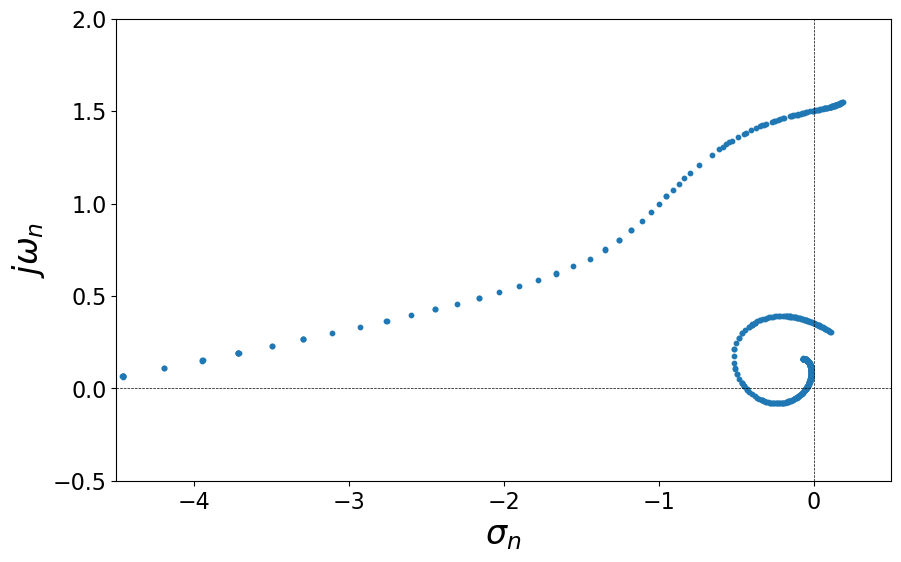

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(poles_evolve.real, -poles_evolve.imag, s=10)
real_axis_x = np.linspace(domain[0], domain[1], 100)
real_axis_y = np.zeros(len(real_axis_x))
imag_axis_y = np.linspace(domain[2], domain[3], 100)
imag_axis_x = np.zeros(len(imag_axis_y))
plt.plot(real_axis_x, real_axis_y, '--k', linewidth=0.5)
plt.plot(imag_axis_x, imag_axis_y, '--k', linewidth=0.5)
plt.xlim([domain[0], domain[1]])
plt.ylim([domain[2], domain[3]])
plt.xlabel(r'$\sigma_{n}$')
plt.ylabel(r'$j \omega_{n}$')

### show the depencency on $\Delta x$
reshape the data in the root_locus dict in order to account for the multiplicity of the poles found with Shot Gun method, and then plot

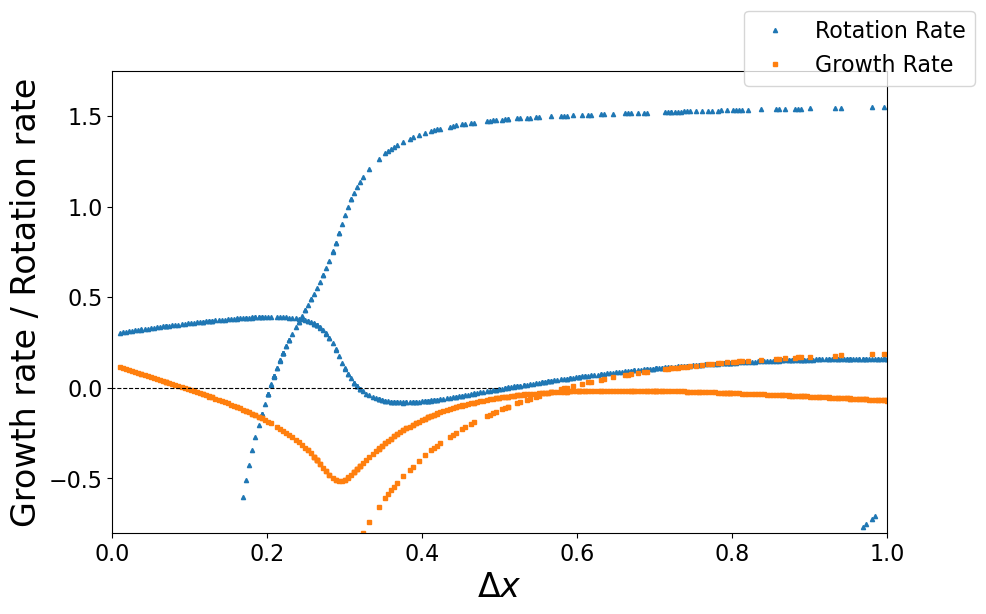

In [7]:
X = np.array([])
growth_rate = np.array([])
rotation_rate = np.array([])

for s in root_locus.keys():
    multiplicity = len(root_locus[s])
    deltaX = np.ones(multiplicity) * s
    X = np.append(X, deltaX)
    pole_plot = root_locus[s]
    growth_rate = np.append(growth_rate, pole_plot.real)
    rotation_rate = np.append(rotation_rate, -pole_plot.imag)
    
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.plot(X, rotation_rate, '^' ,ms=3, label='Rotation Rate')
ax.plot(X, growth_rate, 's', ms=3, label='Growth Rate')
ax.plot(real_axis_x, real_axis_y, '--k', linewidth=0.8)
ax.set_xlabel(r'$\Delta x$')
ax.set_xlim([0, 1])
ax.set_ylim([-0.8, 1.75])
ax.set_ylabel('Growth rate / Rotation rate')
fig.legend()
